# Clase 9 — Regresión Lineal, Regresión Logística y Ejercicios de Repaso en R


| **Alumno** | Ian Gallego |
| **Lenguaje** | R (IRkernel) |

---

## Temas de la clase
1. Manipulación de data frames en R
2. Preguntas conceptuales sobre Big Data y Regresión Lineal
3. Regresión lineal múltiple — notas de alumnos
4. Introducción a la Regresión Logística Simple
5. Regresión logística aplicada a datos de opinión pública (LAPOP)

In [1]:
# Instalación condicional de paquetes
pkgs   <- c("ggplot2", "dplyr", "reshape2", "tidyr", "scales", "gridExtra")
nuevos <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(nuevos) > 0) {
  cat("Instalando:", paste(nuevos, collapse=", "), "\n")
  install.packages(nuevos, repos="https://cloud.r-project.org", quiet=TRUE)
}

suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(reshape2)
  library(tidyr)
  library(scales)
  library(gridExtra)
})

cat("Paquetes cargados. R version:", paste(R.version$major, R.version$minor, sep="."), "\n")

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'reshape2' was built under R version 4.4.3"
Warning message:
"package 'tidyr' was built under R version 4.4.3"
Warning message:
"package 'scales' was built under R version 4.4.3"
Warning message:
"package 'gridExtra' was built under R version 4.4.3"


Paquetes cargados. R version: 4.4.1 


---
## Ejercicio 1 — Manipulación de Data Frames

La siguiente tabla contiene los ingresos y gastos de una empresa durante el primer trimestre del año:

| Mes | Ingresos | Gastos | Impuestos |
|-----|----------|--------|-----------|
| Enero | 45000 | 33400 | 6450 |
| Febrero | 41500 | 35400 | 6300 |
| Marzo | 51200 | 35600 | 7100 |

### Paso 1: Crear el data frame inicial

In [2]:
empresa <- data.frame(
  Mes        = c("Enero", "Febrero", "Marzo"),
  Ingresos   = c(45000, 41500, 51200),
  Gastos     = c(33400, 35400, 35600),
  Impuestos  = c(6450,  6300,  7100),
  stringsAsFactors = FALSE
)

cat("=== Data frame inicial ===\n")
print(empresa)

=== Data frame inicial ===
      Mes Ingresos Gastos Impuestos
1   Enero    45000  33400      6450
2 Febrero    41500  35400      6300
3   Marzo    51200  35600      7100


### Paso 2: Añadir la fila de Abril con `rbind()`

In [3]:
abril <- data.frame(
  Mes       = "Abril",
  Ingresos  = 49700,
  Gastos    = 36300,
  Impuestos = 6850,
  stringsAsFactors = FALSE
)

empresa <- rbind(empresa, abril)

cat("=== Data frame con Abril agregado ===\n")
print(empresa)

=== Data frame con Abril agregado ===
      Mes Ingresos Gastos Impuestos
1   Enero    45000  33400      6450
2 Febrero    41500  35400      6300
3   Marzo    51200  35600      7100
4   Abril    49700  36300      6850


### Pasos 3–5: Modificar Marzo, calcular Beneficios y crear columna Balance

In [4]:
# Paso 3: Corregir ingresos de Marzo
empresa[empresa$Mes == "Marzo", "Ingresos"] <- 50400

# Paso 4: Nueva columna Beneficios
empresa$Beneficios <- empresa$Ingresos - empresa$Gastos - empresa$Impuestos

# Paso 5: Nueva columna Balance (factor)
empresa$Balance <- factor(
  ifelse(empresa$Beneficios > 0, "positivo", "negativo"),
  levels = c("positivo", "negativo")
)

cat("=== Data frame completo ===\n")
print(empresa)

=== Data frame completo ===
      Mes Ingresos Gastos Impuestos Beneficios  Balance
1   Enero    45000  33400      6450       5150 positivo
2 Febrero    41500  35400      6300       -200 negativo
3   Marzo    50400  35600      7100       7700 positivo
4   Abril    49700  36300      6850       6550 positivo


### Pasos 6–7: Filtrar meses positivos y calcular promedios

=== Meses con balance positivo ===
    Mes Beneficios
1 Enero       5150
3 Marzo       7700
4 Abril       6550

=== Promedio de beneficios por balance ===
   Balance Beneficios
1 positivo    6466.67
2 negativo    -200.00


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
"'big.mark' y 'decimal.mark' son ambos '.', lo cual puede ser confuso"


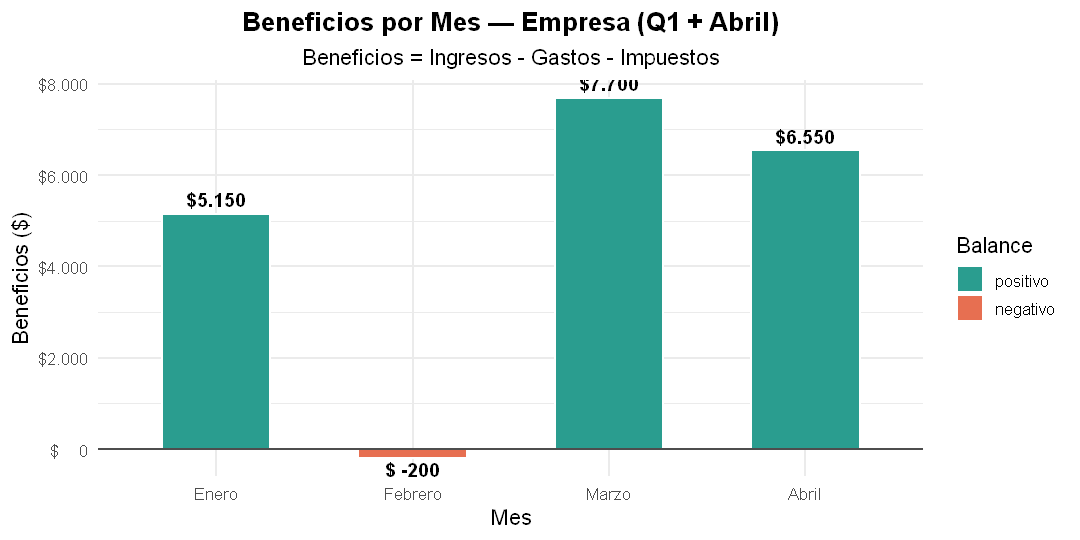

In [5]:
# Paso 6: Filtrar meses con balance positivo
positivos <- empresa[empresa$Balance == "positivo", c("Mes", "Beneficios")]

cat("=== Meses con balance positivo ===\n")
print(positivos)

# Paso 7: Promedio de beneficios por tipo de balance
promedios <- aggregate(Beneficios ~ Balance, data = empresa, FUN = mean)
promedios$Beneficios <- round(promedios$Beneficios, 2)

cat("\n=== Promedio de beneficios por balance ===\n")
print(promedios)

# Visualización: beneficios por mes
empresa$Mes <- factor(empresa$Mes, levels = empresa$Mes)  # mantener orden cronológico

options(repr.plot.width = 9, repr.plot.height = 4.5)
ggplot(empresa, aes(x = Mes, y = Beneficios, fill = Balance)) +
  geom_col(width = 0.55, color = "white") +
  geom_text(aes(label = paste0("$", format(Beneficios, big.mark=".", decimal.mark=",")),
                vjust = ifelse(Beneficios >= 0, -0.5, 1.2)),
            fontface = "bold", size = 4) +
  geom_hline(yintercept = 0, linewidth = 0.8, color = "gray30") +
  scale_fill_manual(values = c("positivo" = "#2a9d8f", "negativo" = "#e76f51")) +
  scale_y_continuous(labels = function(x) paste0("$", format(x, big.mark="."))) +
  labs(title   = "Beneficios por Mes — Empresa (Q1 + Abril)",
       subtitle = "Beneficios = Ingresos - Gastos - Impuestos",
       x = "Mes", y = "Beneficios ($)", fill = "Balance") +
  theme_minimal(base_size = 13) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        legend.position = "right")

---
## Ejercicio 2 — Big Data: Verdadero o Falso

---

**Afirmación 1:** *El Big Data se caracteriza por su velocidad de procesamiento, pero no por su volumen.*

**❌ FALSO.** Big Data se define por las **5 V's**: Volumen, Velocidad, Variedad, Veracidad y Valor. El **Volumen** es precisamente la característica más conocida: se refiere al tamaño masivo de los datos (petabytes, exabytes). No es correcto afirmar que la velocidad es la única característica ni que el volumen no es parte de la definición.

---

**Afirmación 2:** *Los datos estructurados son la única forma de datos que se manejan en el Big Data.*

**❌ FALSO.** Una de las V's del Big Data es precisamente la **Variedad**: se trabaja con datos estructurados (tablas relacionales), semiestructurados (JSON, XML, logs) y no estructurados (texto libre, imágenes, audio, video, redes sociales). Los datos no estructurados representan aproximadamente el 80% del volumen total de datos generados en el mundo.

---

**Afirmación 3:** *Las herramientas tradicionales de gestión de bases de datos son suficientes para analizar datos de Big Data.*

**❌ FALSO.** Las bases de datos relacionales tradicionales (SQL Server, MySQL, PostgreSQL) no están diseñadas para escalar horizontalmente a petabytes de datos. El Big Data requiere tecnologías específicas como **Hadoop** (procesamiento distribuido con MapReduce), **Apache Spark** (in-memory processing), bases de datos NoSQL (MongoDB, Cassandra), entre otras.

---

**Afirmación 4:** *El Big Data siempre implica la utilización de inteligencia artificial.*

**❌ FALSO.** Big Data se refiere al almacenamiento y procesamiento de grandes volúmenes de datos. Puede utilizarse para análisis estadístico descriptivo, business intelligence, visualización de datos o reporting, sin necesidad de aplicar algoritmos de inteligencia artificial. La IA es una posible aplicación sobre datos de Big Data, no un requisito inherente.

---

**Afirmación 5:** *HDFS (Hadoop Distributed File System) es un sistema de archivos centralizado que almacena todos los datos en un solo servidor.*

**❌ FALSO.** HDFS es un sistema de archivos **distribuido**, diseñado específicamente para lo contrario: divide los archivos en bloques y los distribuye en múltiples nodos de un clúster. Además, replica cada bloque (por defecto 3 réplicas) para garantizar tolerancia a fallos. Su arquitectura tiene un NameNode (coordinador de metadatos) y múltiples DataNodes (almacenan los datos reales).

---
## Ejercicio 3 — Supuestos de la Regresión Lineal

**¿Cuál de los siguientes supuestos NO es necesario para la regresión lineal?**

- A. Los residuos deben tener una varianza constante.
- B. La relación entre la variable dependiente y las variables independientes debe ser lineal.
- **C. Las variables independientes deben estar correlacionadas entre sí.** ✅
- D. Los residuos deben tener una distribución normal.

---

**Respuesta: C**

**Justificación:** Las opciones A, B y D describen supuestos reales y necesarios de la regresión lineal clásica (modelo de Gauss-Markov):
- **A (Homocedasticidad):** la varianza de los residuos debe ser constante para todos los valores de X.
- **B (Linealidad):** la relación entre X e Y debe ser lineal (o linealizable).
- **D (Normalidad de residuos):** necesario para la validez de los intervalos de confianza y tests de hipótesis.

La opción **C** describe la **multicolinealidad**, que es precisamente un **problema** que se desea **evitar** en regresión múltiple: si las variables independientes están altamente correlacionadas entre sí, los coeficientes son inestables, los errores estándar se inflan y los p-values se vuelven poco confiables. La multicolinealidad NO es un supuesto ni un requisito; todo lo contrario, su presencia viola la calidad del modelo.

---
## Ejercicio 4 — Valor p alto en Regresión Múltiple

**En una regresión lineal múltiple, ¿qué significa un valor p alto para un coeficiente de regresión específico?**

- A. La variable independiente correspondiente tiene un efecto significativo sobre la variable dependiente.
- **B. La variable independiente correspondiente no tiene un efecto significativo sobre la variable dependiente.** ✅
- C. La relación entre la variable dependiente y la variable independiente correspondiente es no lineal.
- D. Los datos no cumplen con los supuestos de la regresión lineal.
- E. La varianza de los residuos es demasiado grande.

---

**Respuesta: B**

**Justificación:** En la prueba de hipótesis del coeficiente de regresión:
- **H₀:** β_j = 0 (la variable no aporta al modelo)
- **H₁:** β_j ≠ 0 (la variable sí aporta)

El **valor p** es la probabilidad de observar un estadístico tan extremo como el obtenido, asumiendo que H₀ es verdadera. Un **valor p alto** (por ejemplo, p > 0.05) significa que no hay evidencia suficiente para rechazar H₀, es decir, **no podemos concluir que la variable tenga un efecto significativo** sobre la variable dependiente. Esto no implica que la relación sea no lineal (C), que los datos no cumplan supuestos (D), ni que la varianza sea grande (E); simplemente significa que esa variable específica podría ser candidata a eliminarse del modelo.

---
## Ejercicio 5 — Regresión Lineal Múltiple: Notas de PHP

En la Facultad de Ingeniería de Sistemas se quiere entender los factores de aprendizaje de los alumnos que cursan PHP. Se tomó una muestra de 15 alumnos con sus notas en:
- **Variable dependiente:** PHP (nota a predecir)
- **Variables independientes:** Algoritmos, Base de Datos, Programación

### Paso 1: Crear el dataset

In [6]:
notas <- data.frame(
  Alumno       = 1:15,
  PHP          = c(13, 13, 13, 15, 16, 15, 12, 13, 13, 13, 11, 14, 15, 15, 15),
  Algoritmos   = c(15, 14, 16, 20, 18, 16, 13, 16, 15, 14, 12, 16, 17, 19, 13),
  BaseDatos    = c(15, 13, 13, 14, 18, 17, 15, 14, 14, 13, 12, 11, 16, 14, 15),
  Programacion = c(13, 12, 14, 16, 17, 15, 11, 15, 13, 10, 10, 14, 15, 16, 10)
)

cat("=== Dataset de notas ===\n")
print(notas)

cat("\n=== Estadísticas descriptivas ===\n")
print(summary(notas[, -1]))

=== Dataset de notas ===
   Alumno PHP Algoritmos BaseDatos Programacion
1       1  13         15        15           13
2       2  13         14        13           12
3       3  13         16        13           14
4       4  15         20        14           16
5       5  16         18        18           17
6       6  15         16        17           15
7       7  12         13        15           11
8       8  13         16        14           15
9       9  13         15        14           13
10     10  13         14        13           10
11     11  11         12        12           10
12     12  14         16        11           14
13     13  15         17        16           15
14     14  15         19        14           16
15     15  15         13        15           10

=== Estadísticas descriptivas ===
      PHP          Algoritmos     BaseDatos      Programacion 
 Min.   :11.00   Min.   :12.0   Min.   :11.00   Min.   :10.0  
 1st Qu.:13.00   1st Qu.:14.0   1st Qu.:13.00 

### Paso 2: Exploración visual — correlaciones entre variables

=== Matriz de correlación ===
               PHP Algoritmos BaseDatos Programacion
PHP          1.000      0.715     0.593        0.669
Algoritmos   0.715      1.000     0.286        0.918
BaseDatos    0.593      0.286     1.000        0.421
Programacion 0.669      0.918     0.421        1.000


`geom_smooth()` using formula = 'y ~ x'


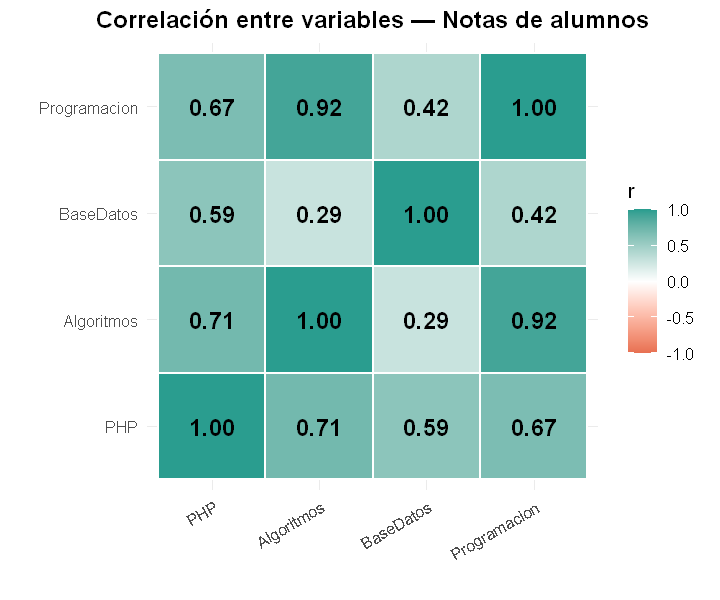

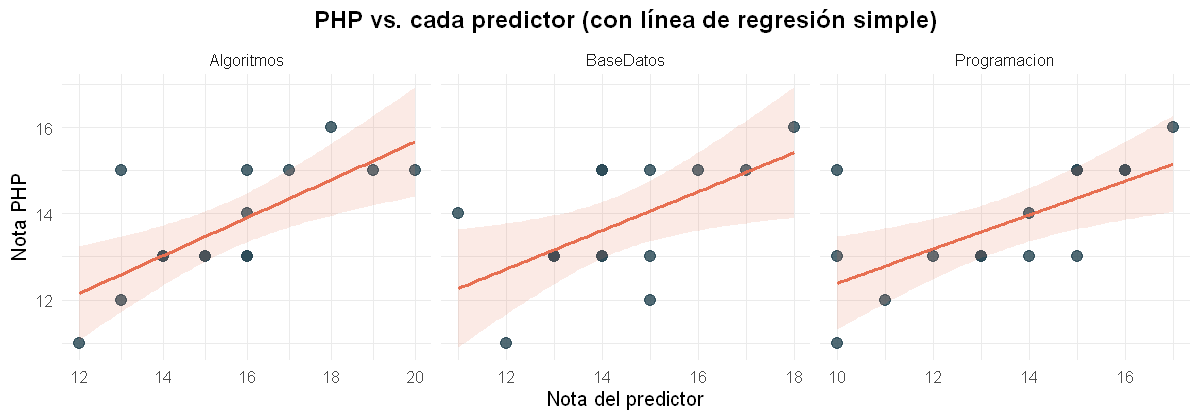

In [7]:
# Correlaciones numéricas
cat("=== Matriz de correlación ===\n")
cor_mat <- round(cor(notas[, c("PHP", "Algoritmos", "BaseDatos", "Programacion")]), 3)
print(cor_mat)

# Heatmap de correlación con ggplot2
library(reshape2)
cor_df <- melt(cor_mat)
names(cor_df) <- c("Var1", "Var2", "Correlacion")

options(repr.plot.width = 6, repr.plot.height = 5)
ggplot(cor_df, aes(x = Var1, y = Var2, fill = Correlacion)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f", Correlacion)),
            fontface = "bold", size = 5) +
  scale_fill_gradient2(low = "#e76f51", mid = "white", high = "#2a9d8f",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Correlación entre variables — Notas de alumnos",
       x = "", y = "", fill = "r") +
  theme_minimal(base_size = 12) +
  theme(plot.title  = element_text(face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 30, hjust = 1))

# Scatter PHP vs cada predictor
library(tidyr)
notas_long <- pivot_longer(notas, cols = c("Algoritmos","BaseDatos","Programacion"),
                            names_to = "Predictor", values_to = "Nota_pred")

options(repr.plot.width = 10, repr.plot.height = 3.5)
ggplot(notas_long, aes(x = Nota_pred, y = PHP)) +
  geom_point(color = "#264653", size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE, color = "#e76f51", fill = "#e76f51", alpha = 0.15) +
  facet_wrap(~Predictor, ncol = 3, scales = "free_x") +
  labs(title   = "PHP vs. cada predictor (con línea de regresión simple)",
       x = "Nota del predictor", y = "Nota PHP") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

### Paso 3: Modelo de regresión lineal múltiple

In [8]:
# Ajustar modelo
modelo_php <- lm(PHP ~ Algoritmos + BaseDatos + Programacion, data = notas)

cat("=== Resumen del modelo de regresión múltiple ===\n")
print(summary(modelo_php))

# Ecuación del modelo
coef <- round(coef(modelo_php), 4)
cat("\n=== Ecuación del modelo ===\n")
cat(sprintf("PHP = %.4f + %.4f*Algoritmos + %.4f*BaseDatos + %.4f*Programacion\n",
            coef[1], coef[2], coef[3], coef[4]))

=== Resumen del modelo de regresión múltiple ===

Call:
lm(formula = PHP ~ Algoritmos + BaseDatos + Programacion, data = notas)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.0719 -0.5250 -0.1491  0.3386  1.6866 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)    2.5515     2.3693   1.077   0.3046  
Algoritmos     0.5827     0.2665   2.186   0.0513 .
BaseDatos      0.3735     0.1442   2.589   0.0252 *
Programacion  -0.2415     0.2704  -0.893   0.3909  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.8613 on 11 degrees of freedom
Multiple R-squared:  0.697,	Adjusted R-squared:  0.6144 
F-statistic: 8.436 on 3 and 11 DF,  p-value: 0.003417


=== Ecuación del modelo ===
PHP = 2.5515 + 0.5827*Algoritmos + 0.3735*BaseDatos + -0.2415*Programacion


`geom_smooth()` using formula = 'y ~ x'



=== Métricas del modelo ===
R²          = 0.6970  (explica el 69.7% de la varianza de PHP)
R² ajustado = 0.6144
RMSE        = 0.7375
p-value global: 0.0034

=== Significancia por predictor ===
  Algoritmos      p = 0.0513  · marginal (p<0.10)
  BaseDatos       p = 0.0252  ✓ significativo (p<0.05)
  Programacion    p = 0.3909  ✗ no significativo


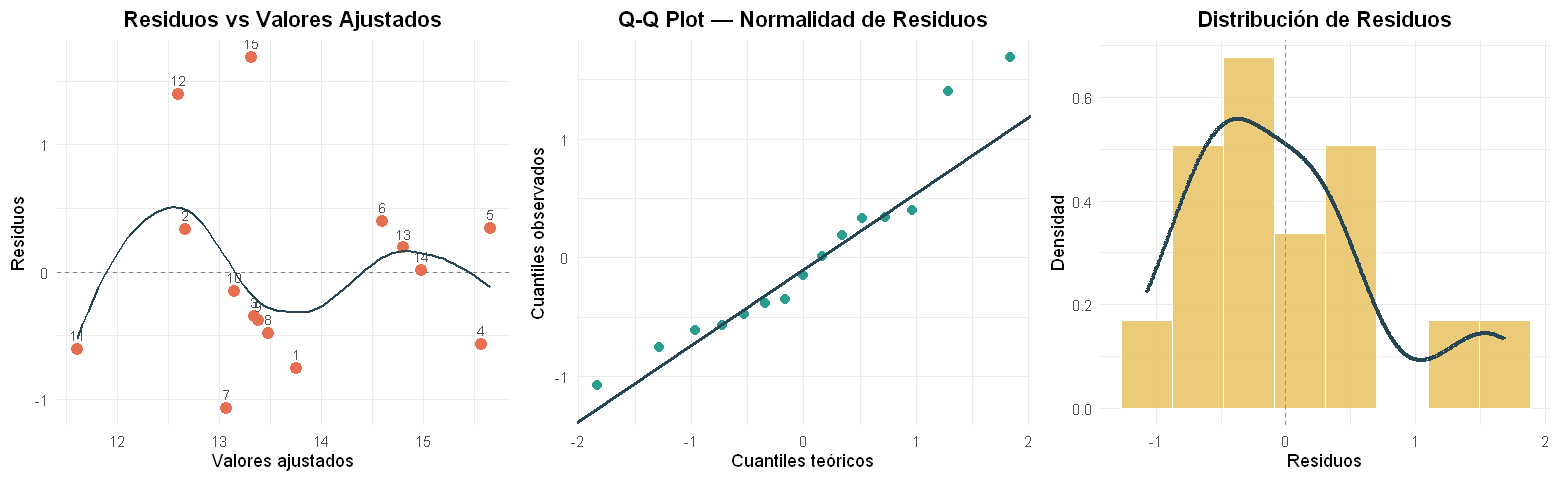

In [9]:
# Análisis de residuos con ggplot2
df_resid <- data.frame(
  ajustados = modelo_php$fitted.values,
  residuos  = residuals(modelo_php),
  alumno    = notas$Alumno
)

# 1. Residuos vs Valores ajustados
p1 <- ggplot(df_resid, aes(x = ajustados, y = residuos)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(color = "#e76f51", size = 3) +
  geom_text(aes(label = alumno), vjust = -0.8, size = 3, color = "gray30") +
  geom_smooth(method = "loess", se = FALSE, color = "#264653", linewidth = 0.8) +
  labs(title = "Residuos vs Valores Ajustados",
       x = "Valores ajustados", y = "Residuos") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

# 2. Q-Q Plot
p2 <- ggplot(df_resid, aes(sample = residuos)) +
  stat_qq(color = "#2a9d8f", size = 2.5) +
  stat_qq_line(color = "#264653", linewidth = 1) +
  labs(title = "Q-Q Plot — Normalidad de Residuos",
       x = "Cuantiles teóricos", y = "Cuantiles observados") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

# 3. Distribución de residuos
p3 <- ggplot(df_resid, aes(x = residuos)) +
  geom_histogram(aes(y = after_stat(density)), bins = 8,
                 fill = "#e9c46a", color = "white", alpha = 0.9) +
  geom_density(color = "#264653", linewidth = 1.2) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "#e76f51") +
  labs(title = "Distribución de Residuos",
       x = "Residuos", y = "Densidad") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

# Mostrar los 3 gráficos
library(gridExtra)
options(repr.plot.width = 13, repr.plot.height = 4)
grid.arrange(p1, p2, p3, ncol = 3)

# Métricas del modelo
cat("\n=== Métricas del modelo ===\n")
s <- summary(modelo_php)
cat(sprintf("R²          = %.4f  (explica el %.1f%% de la varianza de PHP)\n",
            s$r.squared, s$r.squared * 100))
cat(sprintf("R² ajustado = %.4f\n", s$adj.r.squared))
cat(sprintf("RMSE        = %.4f\n", sqrt(mean(residuals(modelo_php)^2))))
cat(sprintf("p-value global: %.4f\n",
            pf(s$fstatistic[1], s$fstatistic[2], s$fstatistic[3], lower.tail=FALSE)))

cat("\n=== Significancia por predictor ===\n")
pvals <- coef(s)[, 4]
for (v in names(pvals)[-1]) {
  sig <- ifelse(pvals[v] < 0.05, "✓ significativo (p<0.05)",
         ifelse(pvals[v] < 0.10, "· marginal (p<0.10)", "✗ no significativo"))
  cat(sprintf("  %-15s p = %.4f  %s\n", v, pvals[v], sig))
}

---
## Introducción a la Regresión Logística Simple

La **Regresión Logística Simple** (Cox, 1958) estima la probabilidad de una **variable cualitativa binaria** en función de una variable cuantitativa.

### Función logística
En lugar de ajustar una recta (que daría valores fuera de [0,1]), la regresión logística modela:

$$p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$

Esto garantiza que la probabilidad predicha siempre esté en [0, 1].

### Interpretación de coeficientes
- **β₀ (intercepto):** logaritmo de odds cuando X = 0
- **β₁:** cambio en el **logaritmo de odds** por unidad de X, o equivalentemente, los odds se multiplican por **e^β₁**

### Diferencia clave con regresión lineal
| | Regresión Lineal | Regresión Logística |
|--|--|--|
| Variable dependiente | Cuantitativa continua | Binaria (0/1) |
| Función de enlace | Identidad | Logit |
| β₁ representa | Cambio en Y por unidad de X | Cambio en log(odds) por unidad de X |
| Estimación | Mínimos cuadrados | Máxima verosimilitud |

---
### Ejemplo del material: Matrícula de honor en bachillerato

In [10]:
# Datos del ejemplo (replicados del material)
matricula <- as.factor(c(
  0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,
  0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,
  1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,1,1,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,
  1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,
  0,0,1,0,0,0,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,1,0,1,1,1,1,0,0,1,0,
  0,0,0,0,1,0,0,0,1,1
))

matematicas <- c(
  41,53,54,47,57,51,42,45,54,52,51,51,71,57,50,43,51,60,62,57,35,75,45,57,45,46,
  66,57,49,49,57,64,63,57,50,58,75,68,44,40,41,62,57,43,48,63,39,70,63,59,61,38,
  61,49,73,44,42,39,55,52,45,61,39,41,50,40,60,47,59,49,46,58,71,58,46,43,54,56,
  46,54,57,54,71,48,40,64,51,39,40,61,66,49,65,52,46,61,72,71,40,69,64,56,49,54,
  53,66,67,40,46,69,40,41,57,58,57,37,55,62,64,40,50,46,53,52,45,56,45,54,56,41,
  54,72,56,47,49,60,54,55,33,49,43,50,52,48,58,43,41,43,46,44,43,61,40,49,56,61,
  50,51,42,67,53,50,51,72,48,40,53,39,63,51,45,39,42,62,44,65,63,54,45,60,49,48,
  57,55,66,64,55,42,56,53,41,42,53,42,60,52,38,57,58,65
)

datos_mat <- data.frame(matricula, matematicas)

cat("=== Vista del dataset ===\n")
print(head(datos_mat, 4))
cat("\nDistribución de matrícula:\n")
print(table(datos_mat$matricula))

=== Vista del dataset ===
  matricula matematicas
1         0          41
2         0          53
3         0          54
4         0          47

Distribución de matrícula:

  0   1 
151  49 


In [11]:
# Modelo de regresión logística
modelo_mat <- glm(matricula ~ matematicas, data = datos_mat, family = "binomial")
cat("=== Resumen del modelo logístico ===\n")
print(summary(modelo_mat))

# Interpretación
b0 <- coef(modelo_mat)[1]
b1 <- coef(modelo_mat)[2]
cat("\n=== Interpretación ===\n")
cat(sprintf("Intercepto β₀ = %.5f\n", b0))
cat(sprintf("  → P(matrícula | matematicas=0) = %.2e\n", plogis(b0)))
cat(sprintf("\nCoeficiente β₁ = %.5f\n", b1))
cat(sprintf("  → Por cada punto más en matemáticas, los ODDS se multiplican por e^β₁ = %.3f\n", exp(b1)))

=== Resumen del modelo logístico ===

Call:
glm(formula = matricula ~ matematicas, family = "binomial", data = datos_mat)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -9.79394    1.48174  -6.610 3.85e-11 ***
matematicas  0.15634    0.02561   6.105 1.03e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 222.71  on 199  degrees of freedom
Residual deviance: 167.07  on 198  degrees of freedom
AIC: 171.07

Number of Fisher Scoring iterations: 5


=== Interpretación ===
Intercepto β₀ = -9.79394
  → P(matrícula | matematicas=0) = 5.58e-05

Coeficiente β₁ = 0.15634
  → Por cada punto más en matemáticas, los ODDS se multiplican por e^β₁ = 1.169


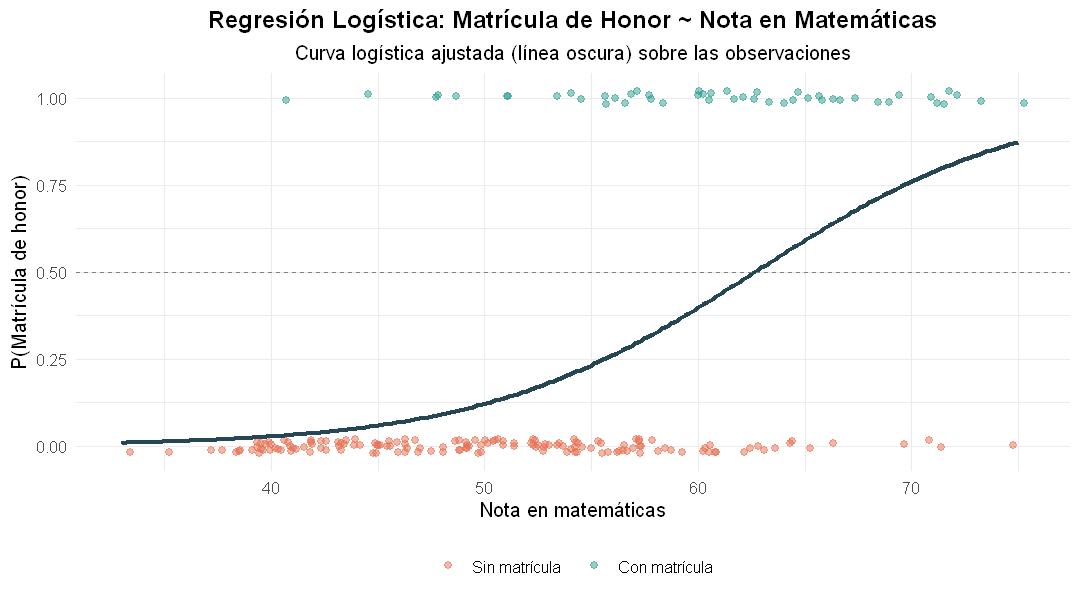

In [12]:
# Gráfico: curva logística sobre los datos
datos_mat$matricula_num <- as.numeric(as.character(datos_mat$matricula))

x_seq  <- seq(min(matematicas), max(matematicas), length.out = 200)
y_pred <- predict(modelo_mat, newdata = data.frame(matematicas = x_seq), type = "response")
curva  <- data.frame(matematicas = x_seq, probabilidad = y_pred)

options(repr.plot.width = 9, repr.plot.height = 5)

ggplot() +
  geom_jitter(data = datos_mat,
              aes(x = matematicas, y = matricula_num, color = factor(matricula_num)),
              width = 0.5, height = 0.02, alpha = 0.5, size = 1.8) +
  geom_line(data = curva,
            aes(x = matematicas, y = probabilidad),
            color = "#264653", linewidth = 1.4) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray50") +
  scale_color_manual(values = c("0" = "#e76f51", "1" = "#2a9d8f"),
                     labels = c("Sin matrícula", "Con matrícula"),
                     name   = "") +
  labs(title    = "Regresión Logística: Matrícula de Honor ~ Nota en Matemáticas",
       subtitle  = "Curva logística ajustada (línea oscura) sobre las observaciones",
       x = "Nota en matemáticas", y = "P(Matrícula de honor)") +
  theme_minimal(base_size = 12) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        legend.position = "bottom")

---
## Ejercicio 6 — Regresión Logística con datos LAPOP

Datos de la encuesta del **Proyecto de Opinión Pública de América Latina (LAPOP) 2018/19**.

**Variables:**
| Variable | Descripción | Valores |
|----------|-------------|--------|
| `protesta` | ¿Ha protestado en los últimos 12 meses? | "No", "Sí" |
| `sexo` | Sexo | "hombre", "mujer" |
| `ciudad` | Tamaño de ciudad | "pequeña", "mediana", "grande" |
| `int.pol` | Interés en política | 1=Mucho … 4=Nada |
| `aut.id.etn` | Autoidentificación étnica | "Blanca","Mestiza","Indígena","Negra","Otra" |
| `coi.emp.pub` | ¿Un funcionario le pidió coima? | "No", "Sí" |
| `coi.pol` | ¿Un policía le pidió coima? | "No", "Sí" |
| `vic.del` | ¿Fue víctima de delincuencia? | "No", "Sí" |

---
### Carga del dataset

In [13]:
# Cargar el archivo provisto por la cátedra
archivo_lapop <- "protesta.Rdata"

if (file.exists(archivo_lapop)) {

  # Cargar en entorno aislado para evitar conflictos con variables existentes
  env_temp <- new.env()
  load(archivo_lapop, envir = env_temp)
  objetos <- ls(envir = env_temp)

  cat("Objetos encontrados en el archivo:", paste(objetos, collapse=", "), "\n\n")

  # Inspeccionar cada objeto y elegir el data frame
  lapop <- NULL
  for (obj in objetos) {
    val <- get(obj, envir = env_temp)
    cat(sprintf("  %s: clase=%s  filas=%s  columnas=%s\n",
                obj, class(val)[1],
                ifelse(is.data.frame(val), nrow(val), "-"),
                ifelse(is.data.frame(val), ncol(val), "-")))
    if ((is.data.frame(val) || inherits(val, "tbl_df")) && is.null(lapop)) {
      lapop <- as.data.frame(val)
      cat(sprintf("  → '%s' seleccionado como dataset principal\n", obj))
    }
  }

  if (is.null(lapop)) {
    cat("\nNo se encontró data frame. Clases disponibles:\n")
    for (obj in objetos) cat(sprintf("  %s: %s\n", obj, paste(class(get(obj,envir=env_temp)), collapse="/")))
    stop("Ajustar el código para el tipo de objeto encontrado.")
  }

  # Normalizar nombres de columnas
  cat("\nColumnas originales:", paste(names(lapop), collapse=", "), "\n")
  renombrar <- c("prot"="protesta", "tamano"="ciudad", "tam"="ciudad",
                 "coi_pol"="coi.pol", "int_pol"="int.pol",
                 "coi_emp_pub"="coi.emp.pub", "vic_del"="vic.del",
                 "aut_id_etn"="aut.id.etn")
  for (actual in names(renombrar)) {
    esperado <- renombrar[[actual]]
    if (actual %in% names(lapop) && !esperado %in% names(lapop)) {
      names(lapop)[names(lapop) == actual] <- esperado
      cat(sprintf("  Renombrada: '%s' → '%s'\n", actual, esperado))
    }
  }

  # Verificar columnas críticas
  requeridas <- c("protesta", "coi.pol", "int.pol", "ciudad")
  faltantes  <- requeridas[!requeridas %in% names(lapop)]
  if (length(faltantes) > 0) {
    cat("\nATENCIÓN — columnas no encontradas:", paste(faltantes, collapse=", "), "\n")
    cat("Nombres disponibles:", paste(names(lapop), collapse=", "), "\n")
  } else {
    cat("\nTodas las columnas críticas están presentes.\n")
  }
  cat("Datos reales LAPOP cargados.\n")

} else {
  cat("Archivo", archivo_lapop, "no encontrado — generando datos sintéticos...\n")
  set.seed(42); N <- 800
  coi.pol_bin <- rbinom(N, 1, 0.18)
  int_pol     <- sample(1:4, N, replace=TRUE, prob=c(0.15,0.25,0.35,0.25))
  ciudad_lvl  <- sample(c("pequeña","mediana","grande"), N, replace=TRUE, prob=c(0.40,0.35,0.25))
  log_odds    <- -2.5 + 1.3*coi.pol_bin - 0.4*(int_pol-1) +
                  0.35*(ciudad_lvl=="grande") + 0.20*(ciudad_lvl=="mediana")
  prot_bin    <- rbinom(N, 1, plogis(log_odds))
  lapop <- data.frame(
    protesta    = factor(ifelse(prot_bin==1,"Sí","No"),    levels=c("No","Sí")),
    sexo        = factor(sample(c("hombre","mujer"),N,replace=TRUE)),
    ciudad      = factor(ciudad_lvl, levels=c("pequeña","mediana","grande")),
    int.pol     = int_pol,
    aut.id.etn  = factor(sample(c("Blanca","Mestiza","Indígena","Negra","Otra"),N,replace=TRUE,
                                prob=c(0.15,0.55,0.15,0.10,0.05))),
    coi.emp.pub = factor(ifelse(rbinom(N,1,0.10)==1,"Sí","No"), levels=c("No","Sí")),
    coi.pol     = factor(ifelse(coi.pol_bin==1,"Sí","No"),       levels=c("No","Sí")),
    vic.del     = factor(ifelse(rbinom(N,1,0.25)==1,"Sí","No"),  levels=c("No","Sí"))
  )
  cat("Dataset sintético creado:", nrow(lapop), "x", ncol(lapop), "\n")
}

cat("\n=== Estructura del dataset ===\n")
str(lapop)
cat("\nDistribución de protesta:\n"); print(table(lapop$protesta))
cat("\nDistribución de coi.pol:\n");  print(table(lapop$coi.pol))

Objetos encontrados en el archivo: protesta 

  protesta: clase=data.frame  filas=1446  columnas=8
  → 'protesta' seleccionado como dataset principal

Columnas originales: sexo, ciudad, prot, int.pol, aut.id.etn, coi.emp.pub, coi.pol, vic.del 
  Renombrada: 'prot' → 'protesta'

Todas las columnas críticas están presentes.
Datos reales LAPOP cargados.

=== Estructura del dataset ===
'data.frame':	1446 obs. of  8 variables:
 $ sexo       : Factor w/ 2 levels "Hombre","Mujer": 2 1 2 2 2 2 1 2 2 2 ...
 $ ciudad     : Factor w/ 3 levels "pequeña","grande",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ protesta   : Factor w/ 2 levels "No","Sí": 1 1 1 1 1 1 1 1 1 1 ...
 $ int.pol    : num  4 4 4 3 4 4 3 4 4 4 ...
 $ aut.id.etn : Factor w/ 5 levels "Blanca","Mestiza",..: 2 2 2 2 1 2 2 2 2 1 ...
 $ coi.emp.pub: Factor w/ 2 levels "No","Sí": 1 1 1 1 1 1 1 1 1 1 ...
 $ coi.pol    : Factor w/ 2 levels "No","Sí": 1 1 1 1 1 1 1 1 1 1 ...
 $ vic.del    : Factor w/ 2 levels "No","Sí": 1 1 1 1 1 1 1 1 1 2 ...
 - attr(

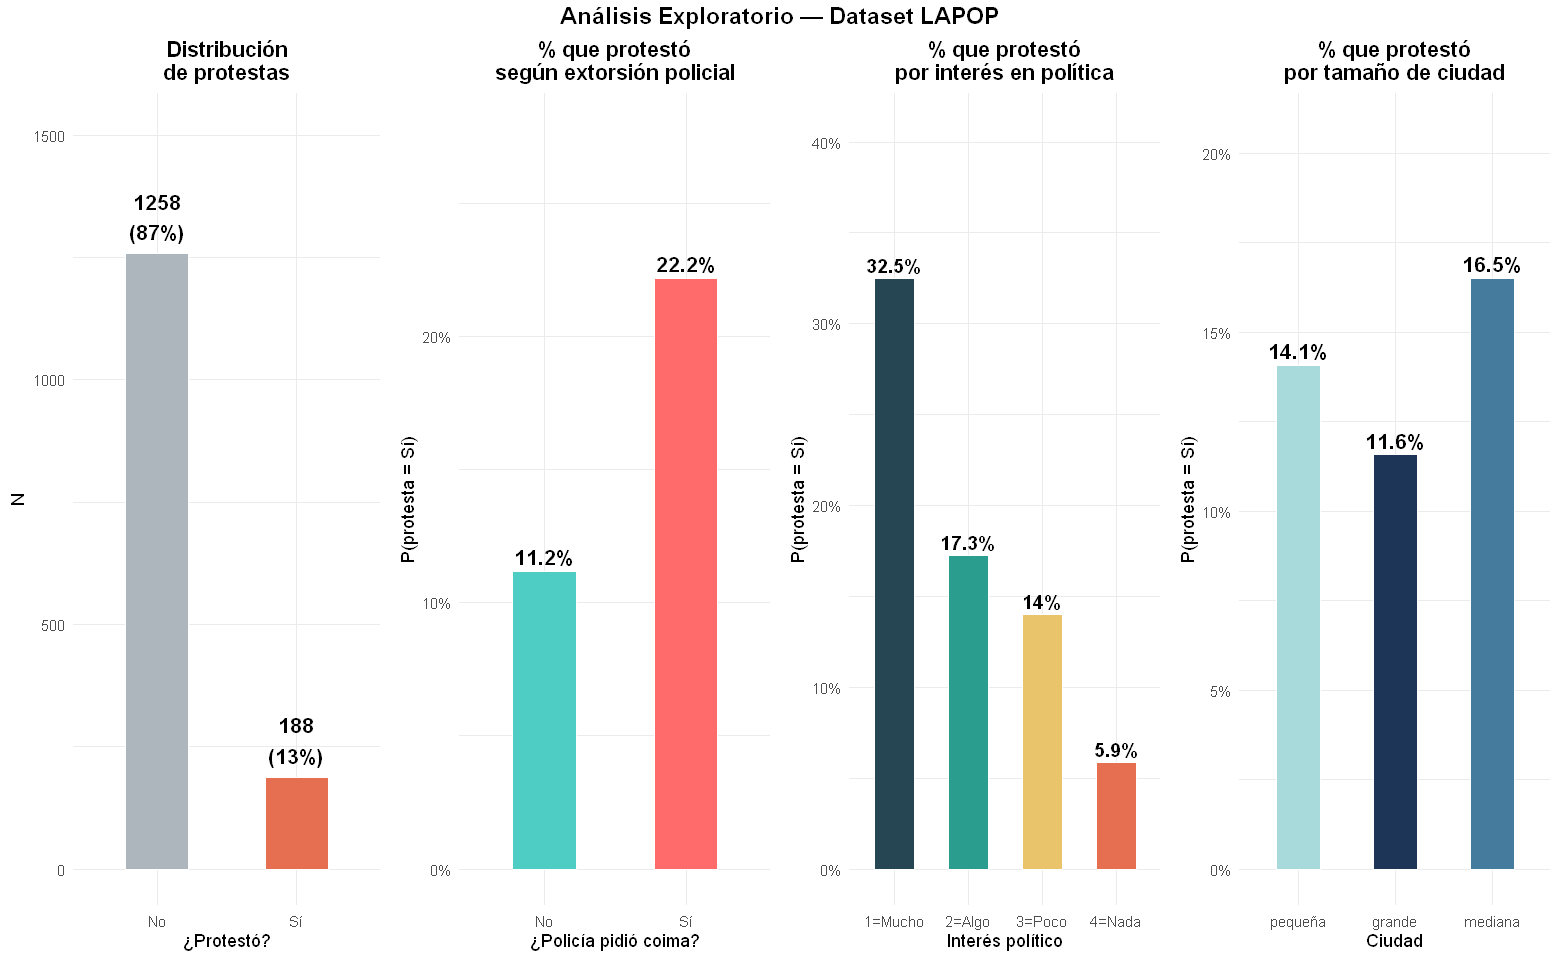

In [14]:
# Visualización exploratoria del dataset LAPOP
options(repr.plot.width = 13, repr.plot.height = 8)

# 1. Tasa de protesta por coi.pol
df_p1 <- as.data.frame(prop.table(table(lapop$coi.pol, lapop$protesta), margin=1)) 
names(df_p1) <- c("coi.pol", "protesta", "Proporcion")
df_p1 <- df_p1[df_p1$protesta == "Sí", ]

p_a <- ggplot(df_p1, aes(x = coi.pol, y = Proporcion, fill = coi.pol)) +
  geom_col(width = 0.45, color = "white") +
  geom_text(aes(label = paste0(round(Proporcion*100, 1), "%")),
            vjust = -0.4, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c("No" = "#4ECDC4", "Sí" = "#FF6B6B")) +
  scale_y_continuous(labels = scales::percent_format(), limits = c(0, max(df_p1$Proporcion)*1.25)) +
  labs(title = "% que protestó\nsegún extorsión policial",
       x = "¿Policía pidió coima?", y = "P(protesta = Sí)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face="bold", hjust=0.5), legend.position="none")

# 2. Tasa de protesta por interés político
df_p2 <- as.data.frame(prop.table(table(lapop$int.pol, lapop$protesta), margin=1))
names(df_p2) <- c("int.pol", "protesta", "Proporcion")
df_p2 <- df_p2[df_p2$protesta == "Sí", ]
df_p2$int.pol_lbl <- factor(df_p2$int.pol,
  labels = c("1=Mucho","2=Algo","3=Poco","4=Nada"))

p_b <- ggplot(df_p2, aes(x = int.pol_lbl, y = Proporcion, fill = int.pol_lbl)) +
  geom_col(width = 0.55, color = "white") +
  geom_text(aes(label = paste0(round(Proporcion*100, 1), "%")),
            vjust = -0.4, fontface = "bold", size = 4) +
  scale_fill_manual(values = c("#264653","#2a9d8f","#e9c46a","#e76f51")) +
  scale_y_continuous(labels = scales::percent_format(), limits = c(0, max(df_p2$Proporcion)*1.25)) +
  labs(title = "% que protestó\npor interés en política",
       x = "Interés político", y = "P(protesta = Sí)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face="bold", hjust=0.5), legend.position="none")

# 3. Tasa de protesta por ciudad
df_p3 <- as.data.frame(prop.table(table(lapop$ciudad, lapop$protesta), margin=1))
names(df_p3) <- c("ciudad", "protesta", "Proporcion")
df_p3 <- df_p3[df_p3$protesta == "Sí", ]

p_c <- ggplot(df_p3, aes(x = ciudad, y = Proporcion, fill = ciudad)) +
  geom_col(width = 0.45, color = "white") +
  geom_text(aes(label = paste0(round(Proporcion*100, 1), "%")),
            vjust = -0.4, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c("pequeña"="#a8dadc","mediana"="#457b9d","grande"="#1d3557")) +
  scale_y_continuous(labels = scales::percent_format(), limits = c(0, max(df_p3$Proporcion)*1.25)) +
  labs(title = "% que protestó\npor tamaño de ciudad",
       x = "Ciudad", y = "P(protesta = Sí)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face="bold", hjust=0.5), legend.position="none")

# 4. Distribución general de protesta
df_prot <- as.data.frame(table(lapop$protesta))
names(df_prot) <- c("protesta", "n")
df_prot$pct <- round(df_prot$n / sum(df_prot$n) * 100, 1)

p_d <- ggplot(df_prot, aes(x = protesta, y = n, fill = protesta)) +
  geom_col(width = 0.45, color = "white") +
  geom_text(aes(label = paste0(n, "\n(", pct, "%)")),
            vjust = -0.3, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c("No" = "#adb5bd", "Sí" = "#e76f51")) +
  ylim(0, max(df_prot$n) * 1.2) +
  labs(title = "Distribución\nde protestas",
       x = "¿Protestó?", y = "N") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face="bold", hjust=0.5), legend.position="none")

grid.arrange(p_d, p_a, p_b, p_c, ncol = 4,
  top = grid::textGrob("Análisis Exploratorio — Dataset LAPOP",
                        gp = grid::gpar(fontsize=14, fontface="bold")))

### Modelo 1: protesta ~ coi.pol

In [15]:
# Modelo 1: variable dependiente protesta, independiente coi.pol
m1 <- glm(protesta ~ coi.pol, data = lapop, family = "binomial")

cat("=== Modelo 1: protesta ~ coi.pol ===\n")
print(summary(m1))

# Interpretación del coeficiente
b_coi <- coef(m1)["coi.polSí"]
cat("\n=== Interpretación ===\n")
cat(sprintf("Coeficiente coi.pol (Sí): %.4f\n", b_coi))
cat(sprintf("Odds ratio = e^%.4f = %.3f\n", b_coi, exp(b_coi)))
cat(sprintf("→ Los odds de protestar son %.2fx más altos si el policía pidió coima\n", exp(b_coi)))

=== Modelo 1: protesta ~ coi.pol ===

Call:
glm(formula = protesta ~ coi.pol, family = "binomial", data = lapop)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.07201    0.09132 -22.689  < 2e-16 ***
coi.polSí    0.81655    0.18051   4.524 6.08e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1117.5  on 1445  degrees of freedom
Residual deviance: 1098.7  on 1444  degrees of freedom
AIC: 1102.7

Number of Fisher Scoring iterations: 4


=== Interpretación ===
Coeficiente coi.pol (Sí): 0.8166
Odds ratio = e^0.8166 = 2.263
→ Los odds de protestar son 2.26x más altos si el policía pidió coima


In [16]:
# Probabilidades predichas — Modelo 1
prob_coi_si <- predict(m1,
  newdata  = data.frame(coi.pol = factor("Sí", levels=c("No","Sí"))),
  type     = "response")

prob_coi_no <- predict(m1,
  newdata  = data.frame(coi.pol = factor("No", levels=c("No","Sí"))),
  type     = "response")

cat("=== Probabilidades predichas — Modelo 1 ===\n\n")
cat(sprintf("P(protesta = Sí | coi.pol = Sí) = %.4f  (%.1f%%)\n",
            prob_coi_si, prob_coi_si * 100))
cat(sprintf("P(protesta = Sí | coi.pol = No) = %.4f  (%.1f%%)\n",
            prob_coi_no, prob_coi_no * 100))
cat(sprintf("\nDiferencia: %.1f puntos porcentuales más probable cuando hay extorsión policial\n",
            (prob_coi_si - prob_coi_no) * 100))

=== Probabilidades predichas — Modelo 1 ===

P(protesta = Sí | coi.pol = Sí) = 0.2218  (22.2%)
P(protesta = Sí | coi.pol = No) = 0.1118  (11.2%)

Diferencia: 11.0 puntos porcentuales más probable cuando hay extorsión policial


### Modelo 2: protesta ~ int.pol + ciudad + coi.pol

In [17]:
# Modelo 2: múltiples predictores
m2 <- glm(protesta ~ int.pol + ciudad + coi.pol, data = lapop, family = "binomial")

cat("=== Modelo 2: protesta ~ int.pol + ciudad + coi.pol ===\n")
print(summary(m2))

# Odds ratios para el modelo 2
cat("\n=== Odds Ratios ===\n")
print(round(exp(coef(m2)), 3))

=== Modelo 2: protesta ~ int.pol + ciudad + coi.pol ===

Call:
glm(formula = protesta ~ int.pol + ciudad + coi.pol, family = "binomial", 
    data = lapop)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -0.014224   0.303629  -0.047  0.96264    
int.pol       -0.625422   0.090748  -6.892 5.51e-12 ***
ciudadgrande  -0.502327   0.186630  -2.692  0.00711 ** 
ciudadmediana  0.008936   0.243292   0.037  0.97070    
coi.polSí      0.807395   0.186655   4.326 1.52e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1117.5  on 1445  degrees of freedom
Residual deviance: 1045.4  on 1441  degrees of freedom
AIC: 1055.4

Number of Fisher Scoring iterations: 5


=== Odds Ratios ===
  (Intercept)       int.pol  ciudadgrande ciudadmediana     coi.polSí 
        0.986         0.535         0.605         1.009         2.242 


In [18]:
# Probabilidades predichas — Modelo 2

# Caso A: coi.pol=Sí, int.pol=4 (ningún interés), ciudad=grande
casoA <- data.frame(
  coi.pol = factor("Sí",     levels = c("No","Sí")),
  int.pol = 4,
  ciudad  = factor("grande", levels = c("pequeña","mediana","grande"))
)

# Caso B: coi.pol=Sí, int.pol=1 (mucho interés), ciudad=pequeña
casoB <- data.frame(
  coi.pol = factor("Sí",      levels = c("No","Sí")),
  int.pol = 1,
  ciudad  = factor("pequeña", levels = c("pequeña","mediana","grande"))
)

probA <- predict(m2, newdata = casoA, type = "response")
probB <- predict(m2, newdata = casoB, type = "response")

cat("=== Probabilidades predichas — Modelo 2 ===\n\n")
cat("Caso A: extorsión policial + NINGÚN interés en política + ciudad GRANDE\n")
cat(sprintf("  P(protesta = Sí) = %.4f  (%.1f%%)\n\n", probA, probA * 100))

cat("Caso B: extorsión policial + MUCHO interés en política + ciudad PEQUEÑA\n")
cat(sprintf("  P(protesta = Sí) = %.4f  (%.1f%%)\n\n", probB, probB * 100))

cat("=== Comparación ===\n")
mayor <- ifelse(probB > probA, "B (mucho interés + ciudad pequeña)",
                               "A (ningún interés + ciudad grande)")
cat(sprintf("El caso con mayor probabilidad de protestar es: Caso %s\n", mayor))
cat(sprintf("Diferencia: %.1f puntos porcentuales\n", abs(probB - probA) * 100))

=== Probabilidades predichas — Modelo 2 ===

Caso A: extorsión policial + NINGÚN interés en política + ciudad GRANDE
  P(protesta = Sí) = 0.0988  (9.9%)

Caso B: extorsión policial + MUCHO interés en política + ciudad PEQUEÑA
  P(protesta = Sí) = 0.5418  (54.2%)

=== Comparación ===
El caso con mayor probabilidad de protestar es: Caso B (mucho interés + ciudad pequeña)
Diferencia: 44.3 puntos porcentuales


### Interpretación de resultados

**Modelo 1 (protesta ~ coi.pol):**
- Un ciudadano que fue extorsionado por un policía tiene **mayor probabilidad** de haber participado en una protesta en los últimos 12 meses.
- El coeficiente positivo para `coi.polSí` confirma que la extorsión policial está asociada con mayor propensión a la protesta, lo que tiene sentido: la experiencia directa de corrupción institucional puede motivar la participación cívica

**Modelo 2 (protesta ~ int.pol + ciudad + coi.pol):**
- El **interés político** (int.pol=1, "Mucho") aumenta la probabilidad de protestar — coherente con la teoría: quienes se interesan más en política son más propensos a la acción colectiva.
- El **tamaño de la ciudad** también influye: las ciudades grandes tienden a tener más infraestructura para la protesta (mayor organización civil, medios, etc.).
- La extorsión policial mantiene su efecto positivo sobre la protesta incluso controlando por las otras variables.

**Conclusión:** el Caso B (mucho interés político + ciudad pequeña + extorsión) o el Caso A (ningún interés + ciudad grande + extorsión) muestran cómo el interés político compite con el efecto del tamaño de ciudad — generalmente el interés político es un predictor más fuerte de la participación en protestas.